# **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,
                             f1_score,
                             recall_score,
                             confusion_matrix,
                             classification_report,
                             precision_score)


print('Everything Loaded Boss')

Everything Loaded Boss


# **Data Exploration**

## *Load The Data*

In [3]:
file_path = input('Enter the File Path: ').replace('\\','\\')
df = pd.read_csv(file_path)
print('Data Loaded Boss')

Data Loaded Boss


## *Exploration*

In [4]:
print(f'The dataset have {df.shape[0]} rows and {df.shape[1]} columns')

The dataset have 655 rows and 8 columns


In [5]:
df.head()

,rainfall_mm,temperature_c,soil_ph,fertilizer_kg,pesticide_use,sunlight_hours,irrigation,crop_failed
0,56.5,33.3,5.11,53.5,1.0,8.2,1.0,1
1,358.3,44.3,6.97,10.4,1.0,11.5,1.0,1
2,150.4,16.0,4.2,197.2,1.0,6.8,0.0,1
3,111.5,26.9,NaN,144.9,0.0,9.8,0.0,0
4,67.5,41.3,5.9,198.2,1.0,8.7,1.0,1


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 655 entries, 0 to 654
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   rainfall_mm     635 non-null    float64
 1   temperature_c   655 non-null    float64
 2   soil_ph         635 non-null    str    
 3   fertilizer_kg   655 non-null    float64
 4   pesticide_use   655 non-null    float64
 5   sunlight_hours  655 non-null    float64
 6   irrigation      655 non-null    float64
 7   crop_failed     655 non-null    int64  
dtypes: float64(6), int64(1), str(1)
memory usage: 43.6 KB


In [7]:
df.describe()

,rainfall_mm,temperature_c,fertilizer_kg,pesticide_use,sunlight_hours,irrigation,crop_failed
count,635.000000,655.000000,655.000000,655.000000,655.000000,655.000000,655.000000
mean,230.280157,30.616641,100.347939,0.567939,7.798473,0.570992,0.465649
std,214.941057,8.896588,59.025725,0.495741,2.442037,0.495313,0.499200
min,50.400000,15.000000,-10.000000,0.000000,4.000000,0.000000,0.000000
25%,132.350000,23.400000,49.450000,0.000000,5.800000,0.000000,0.000000
50%,223.300000,30.900000,100.900000,1.000000,7.800000,1.000000,0.000000
75%,308.050000,38.100000,153.950000,1.000000,9.700000,1.000000,1.000000
max,5000.000000,95.000000,199.800000,1.000000,30.000000,1.000000,1.000000


# **Data Cleaning**

**Create Copy**

In [124]:
df_copy = df.copy()
print('Copy created Boss')

Copy created Boss


**Data Type**

In [125]:
df_copy['soil_ph'] = df_copy['soil_ph'].replace('_err','',regex=True).astype('float')

**Impossible values**

In [126]:
df_copy.loc[df_copy['soil_ph']<0,'soil_ph'] = np.nan
df_copy.loc[df_copy['soil_ph']>14,'soil_ph'] = np.nan

df_copy.loc[df_copy['sunlight_hours']<6,'sunlight_hours'] = np.nan
df_copy.loc[df_copy['sunlight_hours']>14,'sunlight_hours'] = np.nan


**Outliers**

In [127]:
outliers = ['temperature_c','fertilizer_kg','rainfall_mm']

for outlier in outliers:
    Q1 = df_copy[outlier].quantile(0.25)
    Q3 = df_copy[outlier].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_copy.loc[df_copy[outlier] < lower, outlier] = np.nan
    df_copy.loc[df_copy[outlier] > upper, outlier] = np.nan

print("Outliers Handled ✅")

Outliers Handled ✅


**Duplicates**

In [128]:
print(f'Before removing the dataset have {df_copy.duplicated().sum()} duplicates and after cleaning the dataset have {df_copy.drop_duplicates(inplace=True)}')

Before removing the dataset have 15 duplicates and after cleaning the dataset have None


**NaN Values**

In [119]:
# Fill them
columns = ['rainfall_mm','temperature_c','soil_ph','sunlight_hours']

for col in columns:
    df_copy[col] = df_copy[col].fillna(round(df_copy[col].median(),2))
    
print('NaN filled')

NaN filled


In [129]:
# Remove them
print("The Columns have Following NaN values: ")
print(df_copy.isna().sum())
df_copy.dropna(inplace=True)
print("\nThe Columns have Following NaN values After Cleaning: ")
print(df_copy.isna().sum()) 

The Columns have Following NaN values: 
rainfall_mm        21
temperature_c       1
soil_ph            21
fertilizer_kg       0
pesticide_use       0
sunlight_hours    171
irrigation          0
crop_failed         0
dtype: int64

The Columns have Following NaN values After Cleaning: 
rainfall_mm       0
temperature_c     0
soil_ph           0
fertilizer_kg     0
pesticide_use     0
sunlight_hours    0
irrigation        0
crop_failed       0
dtype: int64


# **Data Preperation**

In [130]:
X = df_copy[['rainfall_mm','temperature_c','soil_ph','fertilizer_kg','pesticide_use','sunlight_hours','irrigation']]
y = df_copy['crop_failed']

print(f"X shape: {X.shape}")
print(f'y Shape: {y.shape}')

X shape: (435, 7)
y Shape: (435,)


In [131]:
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.8,random_state=42)


print(f"X_train shape: {X_train.shape}")
print(f'y_train Shape: {y_train.shape}')
print(f'X_test Shape: {X_test.shape}')
print(f'y_test Shape: {y_test.shape}')

X_train shape: (348, 7)
y_train Shape: (348,)
X_test Shape: (87, 7)
y_test Shape: (87,)


# **Models**

## **Decision Tree**

### *Train*

In [137]:
model = DecisionTreeClassifier(max_depth=3,
                               min_samples_leaf=5,
                               min_samples_split=10,
                               random_state=42)

model.fit(X_train,y_train)

print('Model Trained Boss')

Model Trained Boss


### *Test*

In [138]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[34 15]
 [16 22]]
              precision    recall  f1-score   support

           0       0.68      0.69      0.69        49
           1       0.59      0.58      0.59        38

    accuracy                           0.64        87
   macro avg       0.64      0.64      0.64        87
weighted avg       0.64      0.64      0.64        87



### *Features Importance*

          Feature  Importance
2         soil_ph      0.3051
3   fertilizer_kg      0.2700
0     rainfall_mm      0.2598
6      irrigation      0.0844
5  sunlight_hours      0.0807
1   temperature_c      0.0000
4   pesticide_use      0.0000


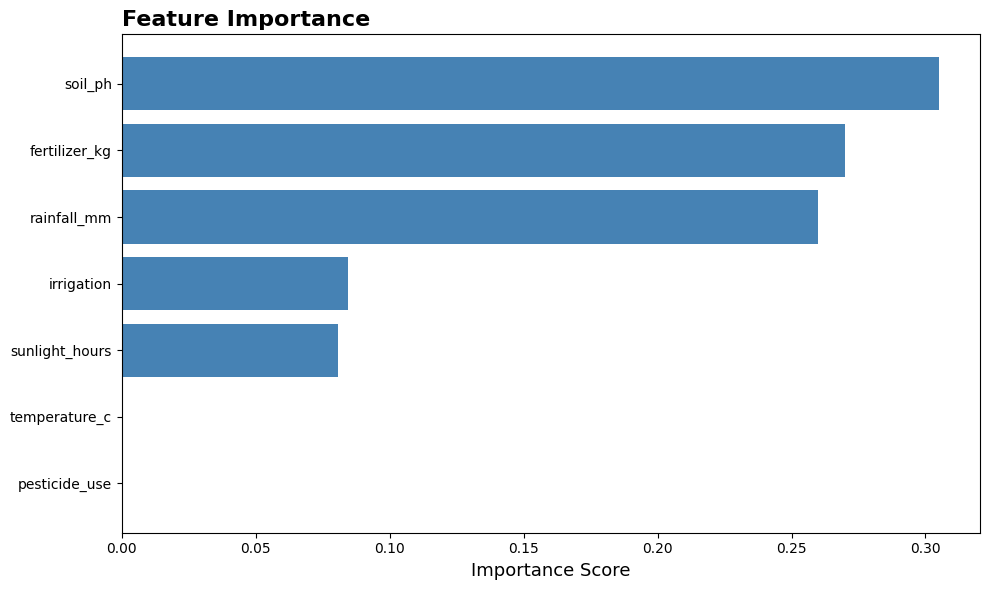

In [139]:
importance = pd.DataFrame({'Feature':X.columns,
                          'Importance': model.feature_importances_.round(4)}).sort_values('Importance',ascending=False)
print(importance)

# Plot it
plt.figure(figsize=(10, 6))
plt.barh(importance['Feature'], 
         importance['Importance'], 
         color='steelblue')
plt.xlabel('Importance Score', fontsize=13)
plt.title('Feature Importance', fontsize=16, 
          fontweight='bold', loc='left')
ax = plt.gca()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### *Tree*

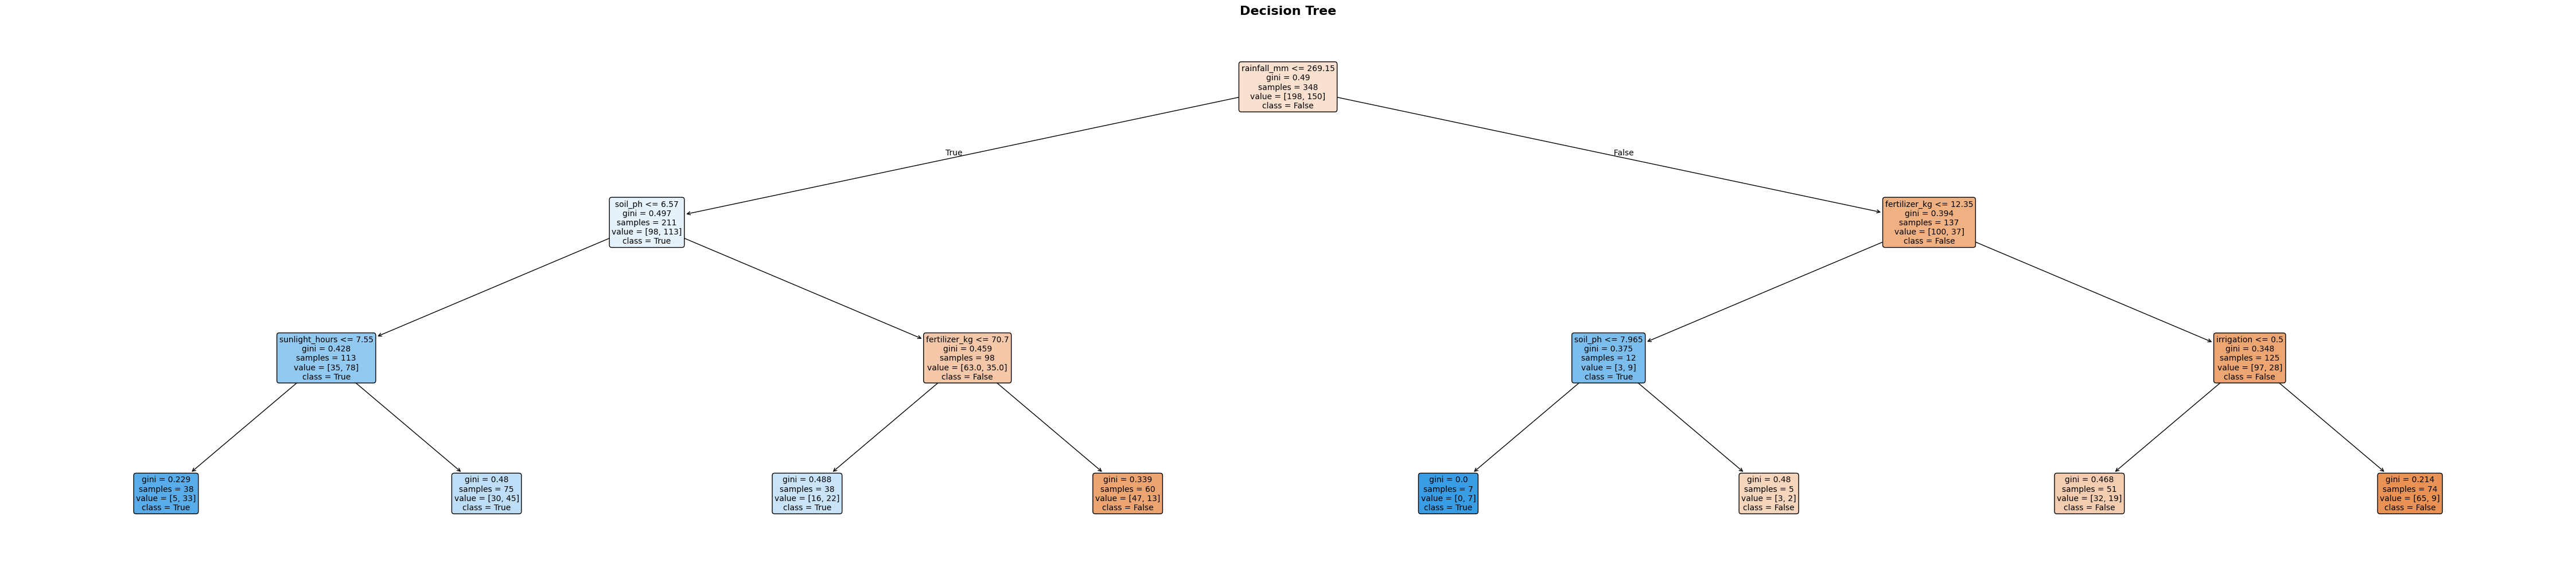

In [140]:
plt.figure(figsize=(45, 10))

plot_tree(
    model,
    feature_names=X.columns.tolist(),
    class_names=['False', 'True'],
    filled=True,          
    rounded=True,         
    fontsize=10
)

plt.title('Decision Tree', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [141]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_acc = accuracy_score(y_train, train_pred)
test_acc  = accuracy_score(y_test, test_pred)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Gap:               {(train_acc - test_acc):.4f}")

Training Accuracy: 0.7299
Testing Accuracy:  0.6437
Gap:               0.0862


### **Chart**

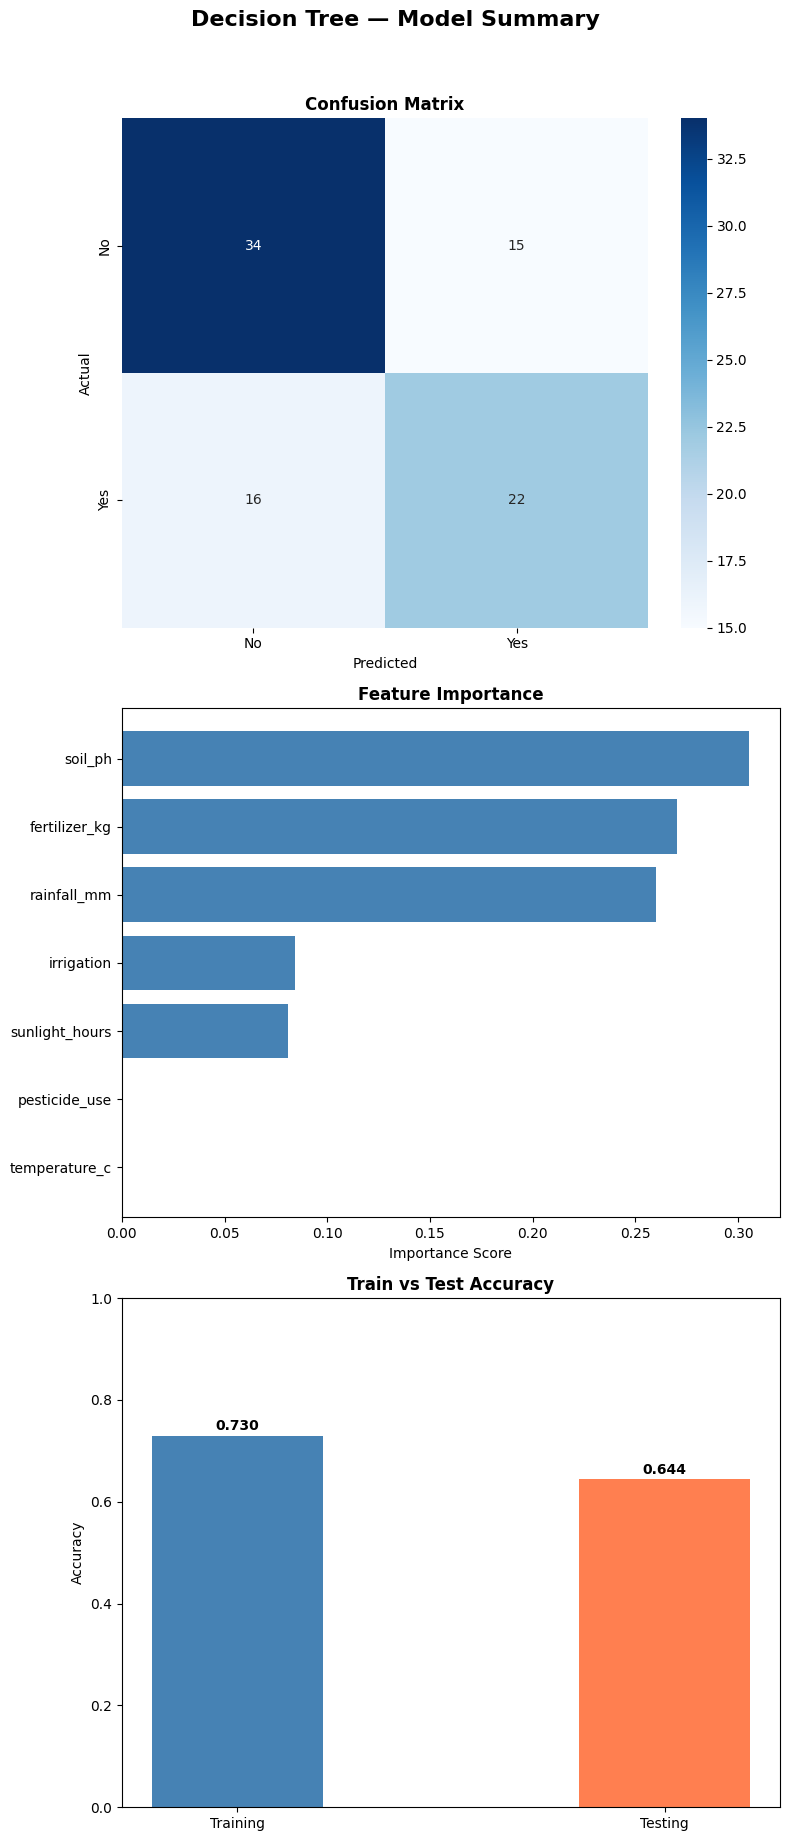

In [143]:
fig, axes = plt.subplots(3, 1, figsize=(8, 18))

# --- Plot 1: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# --- Plot 2: Feature Importance ---
importance_df = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance')

axes[1].barh(importance_df['Feature'],
             importance_df['Importance'],
             color='steelblue')
axes[1].set_title('Feature Importance', fontweight='bold')
axes[1].set_xlabel('Importance Score')

# --- Plot 3: Train vs Test Accuracy ---
labels  = ['Training', 'Testing']
scores  = [train_acc, test_acc]
colors  = ['steelblue', 'coral']

axes[2].bar(labels, scores, color=colors, width=0.4)
axes[2].set_ylim(0, 1)
axes[2].set_title('Train vs Test Accuracy', fontweight='bold')
axes[2].set_ylabel('Accuracy')
for i, v in enumerate(scores):
    axes[2].text(i, v + 0.01, f'{v:.3f}', 
                 ha='center', fontweight='bold')

plt.suptitle('Decision Tree — Model Summary',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## **Logistic regression**

**Train**

In [149]:
model = LogisticRegression(max_iter=200)

model.fit(X_train,y_train)

print('Model trained boss')

Model trained boss


**test**

In [151]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

comparission = pd.DataFrame({'Actual':y_test.values,
                             'Pridicted':y_pred,
                             'Probability':y_prob.round(3)})

print(comparission.head())

   Actual  Pridicted  Probability
0       0          0        0.203
1       1          1        0.638
2       1          1        0.607
3       0          0        0.038
4       0          1        0.525


**Evaluation**

In [157]:
print(f"Accuracy : {round(accuracy_score(y_test,y_pred),4)}")
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:   ", round(recall_score(y_test, y_pred), 4))
print("F1 Score: ", round(f1_score(y_test, y_pred), 4))

Accuracy : 0.7586
Precision: 0.7576
Recall:    0.6579
F1 Score:  0.7042


**Features**

In [158]:
print("Feature Coefficients:")
for feature, coef in zip(X.columns, model.coef_[0]):
    print(f"  {feature:25} → {coef:.4f}")

Feature Coefficients:
  rainfall_mm               → -0.0078
  temperature_c             → 0.0807
  soil_ph                   → -0.4582
  fertilizer_kg             → -0.0101
  pesticide_use             → -0.7946
  sunlight_hours            → -0.3465
  irrigation                → -1.3543


## **Chart**

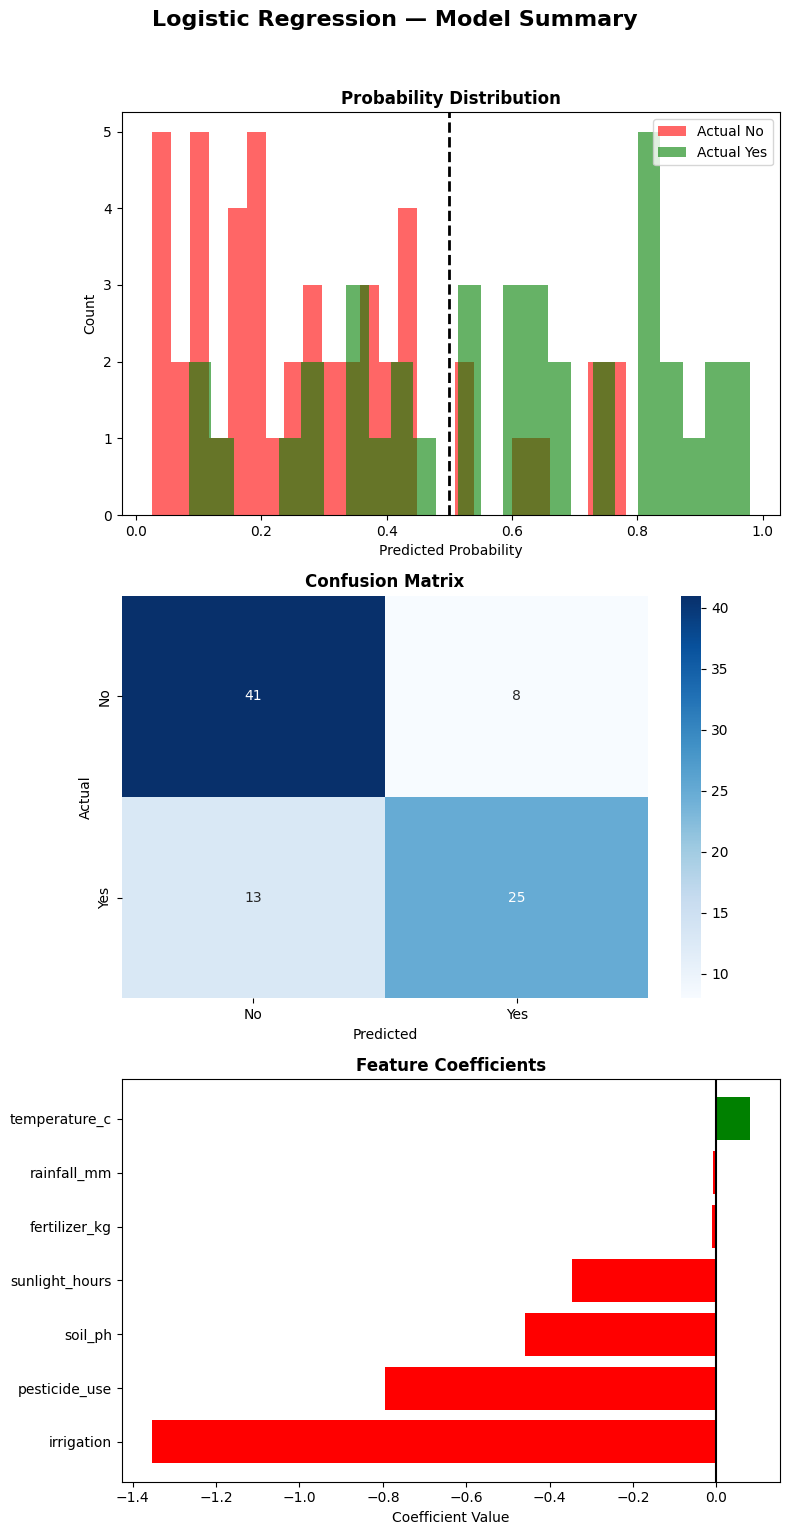

In [159]:
fig, axes = plt.subplots(3, 1, figsize=(8, 15))

# --- Plot 1: Probability Distribution ---
axes[0].hist(y_prob[y_test == 0], bins=25, alpha=0.6,
             color='red', label='Actual No')
axes[0].hist(y_prob[y_test == 1], bins=25, alpha=0.6,
             color='green', label='Actual Yes')
axes[0].axvline(x=0.5, color='black', linestyle='--', linewidth=2)
axes[0].set_title('Probability Distribution', fontweight='bold')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Count')
axes[0].legend()

# --- Plot 2: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])
axes[1].set_title('Confusion Matrix', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# --- Plot 3: Feature Coefficients ---
coef_df = pd.DataFrame({
    'Feature':     X.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient')
colors = ['red' if c < 0 else 'green' for c in coef_df['Coefficient']]
axes[2].barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
axes[2].axvline(x=0, color='black', linewidth=1.5)
axes[2].set_title('Feature Coefficients', fontweight='bold')
axes[2].set_xlabel('Coefficient Value')

plt.suptitle('Logistic Regression — Model Summary', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
